# MScFE 642 GWP2 - Leakage, Walk-Forward Backtesting, and Embargo

Asset: SPY (SPDR S&P 500 ETF)  
Models: MLP, LSTM, CNN-GAF  
Task: binary classification of future return direction

This notebook is written for Google Colab. It corrects the earlier version by adding the LSTM model, making the label construction safer, setting stronger random seed controls, and aligning the Step 3 numbering with the assignment.

Run all cells from the top. At the end, the notebook saves CSV tables and figures in `/content/gwp2_outputs/`.

## Step 0. Install packages and set reproducibility controls

The results of neural networks can still change a little by hardware and TensorFlow version. The settings below reduce that problem. They also make the final run easier to repeat.

In [23]:
# Colab install cell
!pip -q install yfinance pyts scikit-learn tensorflow

In [24]:
import os

# Set environment variables before TensorFlow import.
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["CUDA_ENABLE_CUDNN_DETERMINISTIC_OPS"] = "1"  # This one is new
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from pyts.image import GramianAngularField

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as err:
    print("Determinism function was not available:", err)

try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except Exception as err:
    print("Thread setting skipped:", err)

OUT_DIR = "/content/gwp2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print("TensorFlow:", tf.__version__)
print("Output folder:", OUT_DIR)

TensorFlow: 2.20.0
Output folder: /content/gwp2_outputs


## Step 1a. Gather and describe the data

We use daily adjusted closing prices for SPY. The sample is capped at 2,000 observations as required by the assignment.

In [25]:
TICKER = "SPY"
START_DATE = "2016-01-01"
END_DATE = "2023-12-31"
MAX_OBS = 2000

raw0 = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

# Some yfinance versions return a MultiIndex even for one ticker.
if isinstance(raw0.columns, pd.MultiIndex):
    raw0.columns = raw0.columns.get_level_values(0)

raw = raw0[["Close"]].dropna().copy()
raw.columns = ["Close"]
raw = raw.iloc[-MAX_OBS:].copy()

print(f"Sample: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Observations: {len(raw)}")
display(raw.head())

Sample: 2016-01-21 to 2023-12-29
Observations: 2000


,Close
Date,
2016-01-21,157.390533
2016-01-22,160.619446
2016-01-25,158.191391
2016-01-26,160.349640
2016-01-27,158.604553


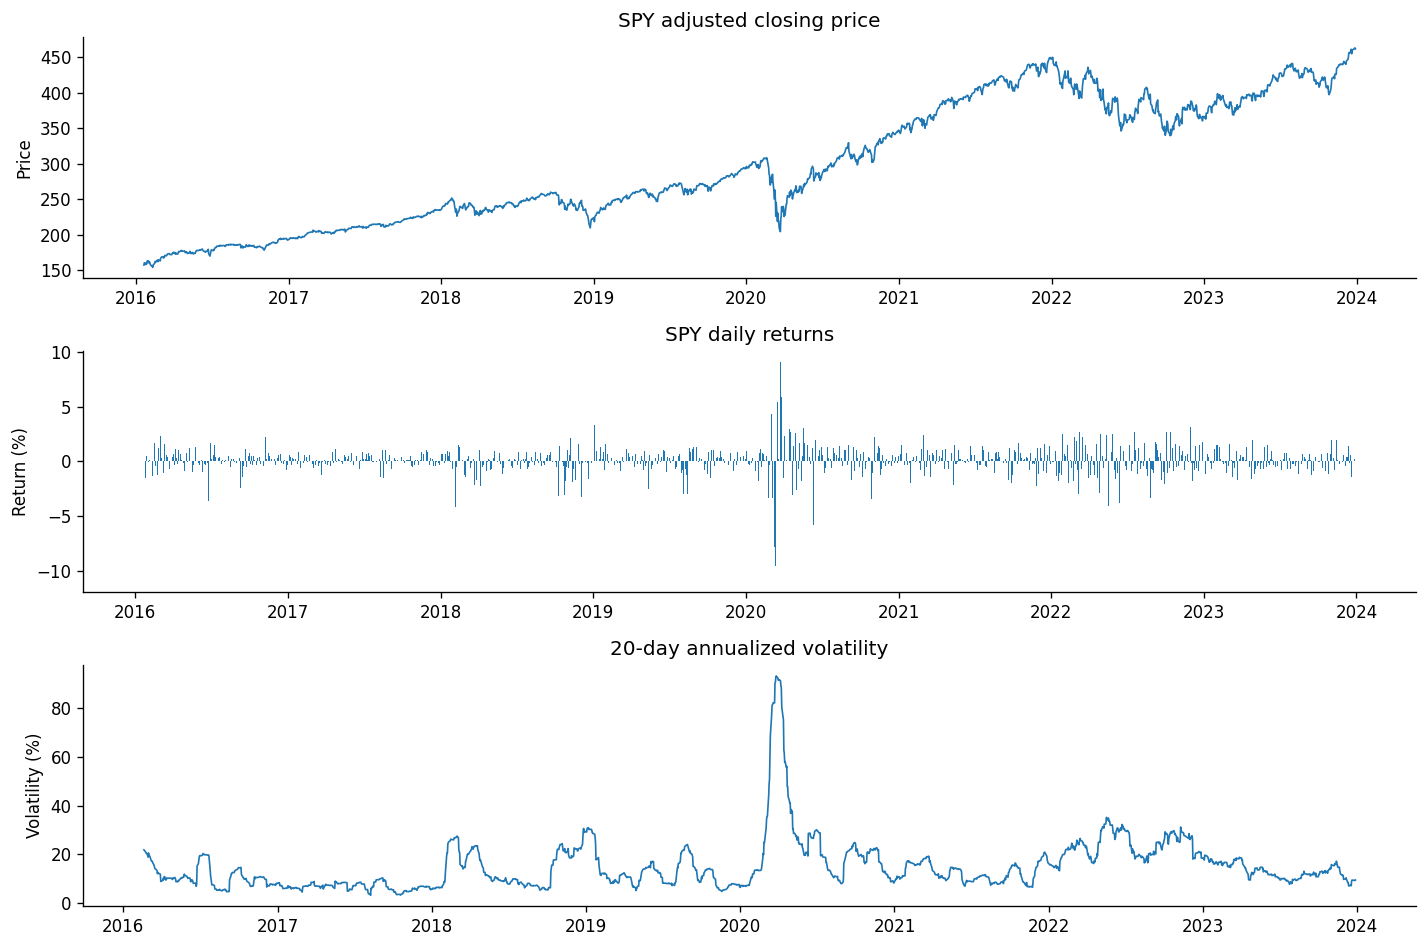

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Daily return,1999.0,0.00061,0.01157,-0.10942,-0.00364,0.00064,0.00599,0.0906,-0.57329,13.33356


In [26]:
ret = raw["Close"].pct_change().dropna()
vol20 = ret.rolling(20).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(raw.index, raw["Close"], lw=1)
axes[0].set_title("SPY adjusted closing price")
axes[0].set_ylabel("Price")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].bar(ret.index, ret * 100, width=1)
axes[1].set_title("SPY daily returns")
axes[1].set_ylabel("Return (%)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[2].plot(vol20.index, vol20, lw=1)
axes[2].set_title("20-day annualized volatility")
axes[2].set_ylabel("Volatility (%)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_01_data_description.png", bbox_inches="tight")
plt.show()

summary_stats = ret.describe().to_frame("Daily return").T
summary_stats["skewness"] = ret.skew()
summary_stats["kurtosis"] = ret.kurt()
summary_stats = summary_stats.round(5)
display(summary_stats)
summary_stats.to_csv(f"{OUT_DIR}/table_01_summary_stats.csv")

## Step 1b. Build labels with deliberate leakage

The features use past returns. The label uses the next 20 trading days:

`label_t = 1 if SPY return from t to t + 20 is positive, otherwise 0`.

This creates overlapping labels. Near a train/test boundary, the last training labels use prices that are inside the test period. This is a deliberate leakage channel. In Step 1 we also create a second leakage channel by fitting the scaler on the full dataset before the single train/test split.

The code avoids the common mistake of turning a missing future label into zero. It first creates the future return, drops missing values, and only then converts the label to 0 or 1.

In [27]:
LOOKBACK = 20
HORIZON = 20
TCOST = 0.0005

# Main dataframe.
df = pd.DataFrame(index=raw.index)
df["Close"] = raw["Close"]
df["r"] = df["Close"].pct_change()

# Lag features.
for k in range(1, LOOKBACK + 1):
    df[f"lag_{k}"] = df["r"].shift(k)

# Simple technical features.
df["mom_5"] = df["r"].rolling(5).mean()
df["vol_20"] = df["r"].rolling(20).std()
df["zscore_20"] = (df["r"] - df["r"].rolling(20).mean()) / (df["r"].rolling(20).std() + 1e-12)

# RSI(14).
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / (loss + 1e-12)
    return 100 - (100 / (1 + rs))

df["rsi_14"] = compute_rsi(df["Close"], period=14)

# Future return label. This is made before dropping NaN values.
df["fwd_ret_h"] = df["Close"].shift(-HORIZON) / df["Close"] - 1

# This one-day return is used for the trading backtest. It is aligned to the prediction date.
df["trade_ret_1"] = df["Close"].shift(-1) / df["Close"] - 1

FEATURE_COLS = [f"lag_{k}" for k in range(1, LOOKBACK + 1)] + ["mom_5", "vol_20", "zscore_20", "rsi_14"]
use_cols = FEATURE_COLS + ["fwd_ret_h", "trade_ret_1"]
df = df.dropna(subset=use_cols).copy()
df["label"] = (df["fwd_ret_h"] > 0).astype(int)

X_all = df[FEATURE_COLS].values.astype("float32")
y_all = df["label"].values.astype("int32")
dates_all = df.index

LAG_COLS = [f"lag_{k}" for k in range(1, LOOKBACK + 1)]
LAG_POS = [FEATURE_COLS.index(c) for c in LAG_COLS]

print("Feature matrix:", X_all.shape)
print("Label horizon:", HORIZON, "trading days")
print("Label balance:")
display(pd.Series(y_all).value_counts(normalize=True).rename("share").round(3))

Feature matrix: (1959, 24)
Label horizon: 20 trading days
Label balance:


,share
1,0.691
0,0.309


## Step 1c. Build the three models

We use three models because the team has three members: MLP, LSTM, and CNN-GAF.

In [28]:
GAF_WINDOW = LOOKBACK
gaf = GramianAngularField(image_size=GAF_WINDOW, method="summation")

# Set this to True only for debugging. Keep False for the final report run.
FAST_RUN = False
EPOCHS_SINGLE = 80 if not FAST_RUN else 3
EPOCHS_WF = 40 if not FAST_RUN else 3
BATCH = 64
MAX_FOLDS = None if not FAST_RUN else 2

MODEL_ORDER = ["MLP", "LSTM", "CNN-GAF"]

def reset_keras(seed=SEED):
    keras.backend.clear_session()
    gc.collect()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def get_callbacks(patience=6):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, patience // 2), verbose=0),
    ]


def make_lstm_sequences(X_scaled):
    # lag_20 ... lag_1 gives the LSTM the sequence in older-to-newer order.
    x_lag = X_scaled[:, LAG_POS][:, ::-1]
    return x_lag[..., np.newaxis].astype("float32")


def make_gaf_images(X_scaled):
    # Use the same lag sequence for the image model.
    x_lag = X_scaled[:, LAG_POS][:, ::-1]
    imgs = gaf.fit_transform(x_lag)
    return imgs[..., np.newaxis].astype("float32")


def build_mlp(n_features):
    inp = layers.Input(shape=(n_features,))
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.15)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_lstm(seq_len=LOOKBACK):
    inp = layers.Input(shape=(seq_len, 1))
    x = layers.LSTM(32, return_sequences=False, dropout=0.10, recurrent_dropout=0.0)(inp)
    x = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.15)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_cnn_gaf(img_size=GAF_WINDOW):
    inp = layers.Input(shape=(img_size, img_size, 1))
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

print("Models ready:", MODEL_ORDER)

Models ready: ['MLP', 'LSTM', 'CNN-GAF']


In [29]:
def clf_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "AUC-ROC": round(float(auc), 4) if np.isfinite(auc) else np.nan,
    }


def train_predict_model(model_name, X_tr_scaled, y_tr, X_te_scaled, epochs, batch=BATCH, seed=SEED):
    reset_keras(seed)
    cbs = get_callbacks(patience=6)

    if model_name == "MLP":
        model = build_mlp(X_tr_scaled.shape[1])
        model.fit(X_tr_scaled, y_tr, validation_split=0.15, epochs=epochs, batch_size=batch,
                  callbacks=cbs, verbose=0, shuffle=False)
        prob = model.predict(X_te_scaled, verbose=0).ravel()

    elif model_name == "LSTM":
        Xtr = make_lstm_sequences(X_tr_scaled)
        Xte = make_lstm_sequences(X_te_scaled)
        model = build_lstm(seq_len=LOOKBACK)
        model.fit(Xtr, y_tr, validation_split=0.15, epochs=epochs, batch_size=batch,
                  callbacks=cbs, verbose=0, shuffle=False)
        prob = model.predict(Xte, verbose=0).ravel()

    elif model_name == "CNN-GAF":
        Xtr = make_gaf_images(X_tr_scaled)
        Xte = make_gaf_images(X_te_scaled)
        model = build_cnn_gaf(img_size=GAF_WINDOW)
        model.fit(Xtr, y_tr, validation_split=0.15, epochs=epochs, batch_size=batch,
                  callbacks=cbs, verbose=0, shuffle=False)
        prob = model.predict(Xte, verbose=0).ravel()

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return prob


def backtest_from_predictions(dates, probabilities, threshold=0.5, tcost=TCOST):
    dates = pd.Index(dates)
    prob = np.asarray(probabilities).ravel()[:len(dates)]
    position = (prob >= threshold).astype(int)
    trade_ret = df.loc[dates, "trade_ret_1"].values[:len(position)]

    # Transaction cost is charged when the position changes.
    trades = np.abs(np.diff(np.r_[0, position]))
    strategy_ret = position * trade_ret - trades * tcost
    bh_ret = trade_ret

    out = pd.DataFrame(index=dates[:len(position)])
    out["position"] = position
    out["strategy_ret"] = strategy_ret
    out["buy_hold_ret"] = bh_ret
    out["Strategy"] = (1 + out["strategy_ret"]).cumprod()
    out["Buy & Hold"] = (1 + out["buy_hold_ret"]).cumprod()
    return out


def sharpe_from_returns(ret, rf=0.0):
    ret = pd.Series(ret).dropna()
    if ret.std() == 0 or len(ret) == 0:
        return np.nan
    return (ret.mean() - rf / 252) / (ret.std() + 1e-12) * np.sqrt(252)


def max_drawdown(cum):
    cum = pd.Series(cum).dropna()
    dd = cum / cum.cummax() - 1
    return dd.min()


def backtest_stats(bt_df, protocol, model_name):
    return {
        "Protocol": protocol,
        "Model": model_name,
        "Total Return": round((bt_df["Strategy"].iloc[-1] - 1) * 100, 2),
        "Buy & Hold Return": round((bt_df["Buy & Hold"].iloc[-1] - 1) * 100, 2),
        "Sharpe": round(sharpe_from_returns(bt_df["strategy_ret"]), 3),
        "B&H Sharpe": round(sharpe_from_returns(bt_df["buy_hold_ret"]), 3),
        "Max Drawdown": round(max_drawdown(bt_df["Strategy"]) * 100, 2),
        "Exposure": round(bt_df["position"].mean(), 3),
        "Trades": int(np.abs(np.diff(np.r_[0, bt_df["position"].values])).sum()),
    }


def plot_backtests(bt_dict, title, filename):
    n = len(bt_dict)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.4 * n), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, (name, bt) in zip(axes, bt_dict.items()):
        ax.plot(bt.index, bt["Strategy"], label="Strategy", lw=1.2)
        ax.plot(bt.index, bt["Buy & Hold"], label="Buy & Hold", lw=1.0, ls="--")
        ax.set_title(name)
        ax.set_ylabel("Cumulative return")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    fig.savefig(f"{OUT_DIR}/{filename}", bbox_inches="tight")
    plt.show()

## Step 1c. Single train/test split with deliberate leakage

The scaler is fitted on the full dataset before splitting. This means the training set uses distribution information from the test set. This split is intentionally weak and should not be trusted as a real out-of-sample test.

In [30]:
# Leaky full-sample scaling.
leaky_scaler = StandardScaler().fit(X_all)
X_leaky = leaky_scaler.transform(X_all).astype("float32")

split_idx = int(len(X_leaky) * 0.70)
X_tr_lk, X_te_lk = X_leaky[:split_idx], X_leaky[split_idx:]
y_tr_lk, y_te_lk = y_all[:split_idx], y_all[split_idx:]
dates_te_lk = dates_all[split_idx:]

print(f"Train observations: {len(y_tr_lk)}")
print(f"Test observations:  {len(y_te_lk)}")
print(f"Train period: {dates_all[0].date()} to {dates_all[split_idx-1].date()}")
print(f"Test period:  {dates_te_lk[0].date()} to {dates_te_lk[-1].date()}")

step1_metrics = []
step1_bt_stats = []
step1_bt = {}
step1_prob = {}

for i, model_name in enumerate(MODEL_ORDER):
    print("Training", model_name, "for Step 1")
    prob = train_predict_model(model_name, X_tr_lk, y_tr_lk, X_te_lk, epochs=EPOCHS_SINGLE, seed=SEED + i)
    step1_prob[model_name] = prob
    met = clf_metrics(y_te_lk, prob)
    met.update({"Protocol": "Step 1 - leaky single split", "Model": model_name})
    step1_metrics.append(met)

    bt = backtest_from_predictions(dates_te_lk, prob)
    step1_bt[model_name] = bt
    step1_bt_stats.append(backtest_stats(bt, "Step 1 - leaky single split", model_name))

step1_metrics_df = pd.DataFrame(step1_metrics)[["Protocol", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]]
step1_bt_df = pd.DataFrame(step1_bt_stats)

display(step1_metrics_df)
display(step1_bt_df)

step1_metrics_df.to_csv(f"{OUT_DIR}/table_02_step1_classification.csv", index=False)
step1_bt_df.to_csv(f"{OUT_DIR}/table_03_step1_backtest.csv", index=False)



Train observations: 1371
Test observations:  588
Train period: 2016-02-22 to 2021-07-30
Test period:  2021-08-02 to 2023-11-30
Training MLP for Step 1
Training LSTM for Step 1
Training CNN-GAF for Step 1


,Protocol,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Step 1 - leaky single split,MLP,0.5357,0.5397,0.9812,0.6963,0.5219
1,Step 1 - leaky single split,LSTM,0.5425,0.5425,1.0000,0.7034,0.4863
2,Step 1 - leaky single split,CNN-GAF,0.5425,0.5425,1.0000,0.7034,0.4804


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 1 - leaky single split,MLP,7.38,8.53,0.257,0.281,-23.74,0.986,15
1,Step 1 - leaky single split,LSTM,8.47,8.53,0.280,0.281,-24.50,1.000,1
2,Step 1 - leaky single split,CNN-GAF,8.47,8.53,0.280,0.281,-24.50,1.000,1


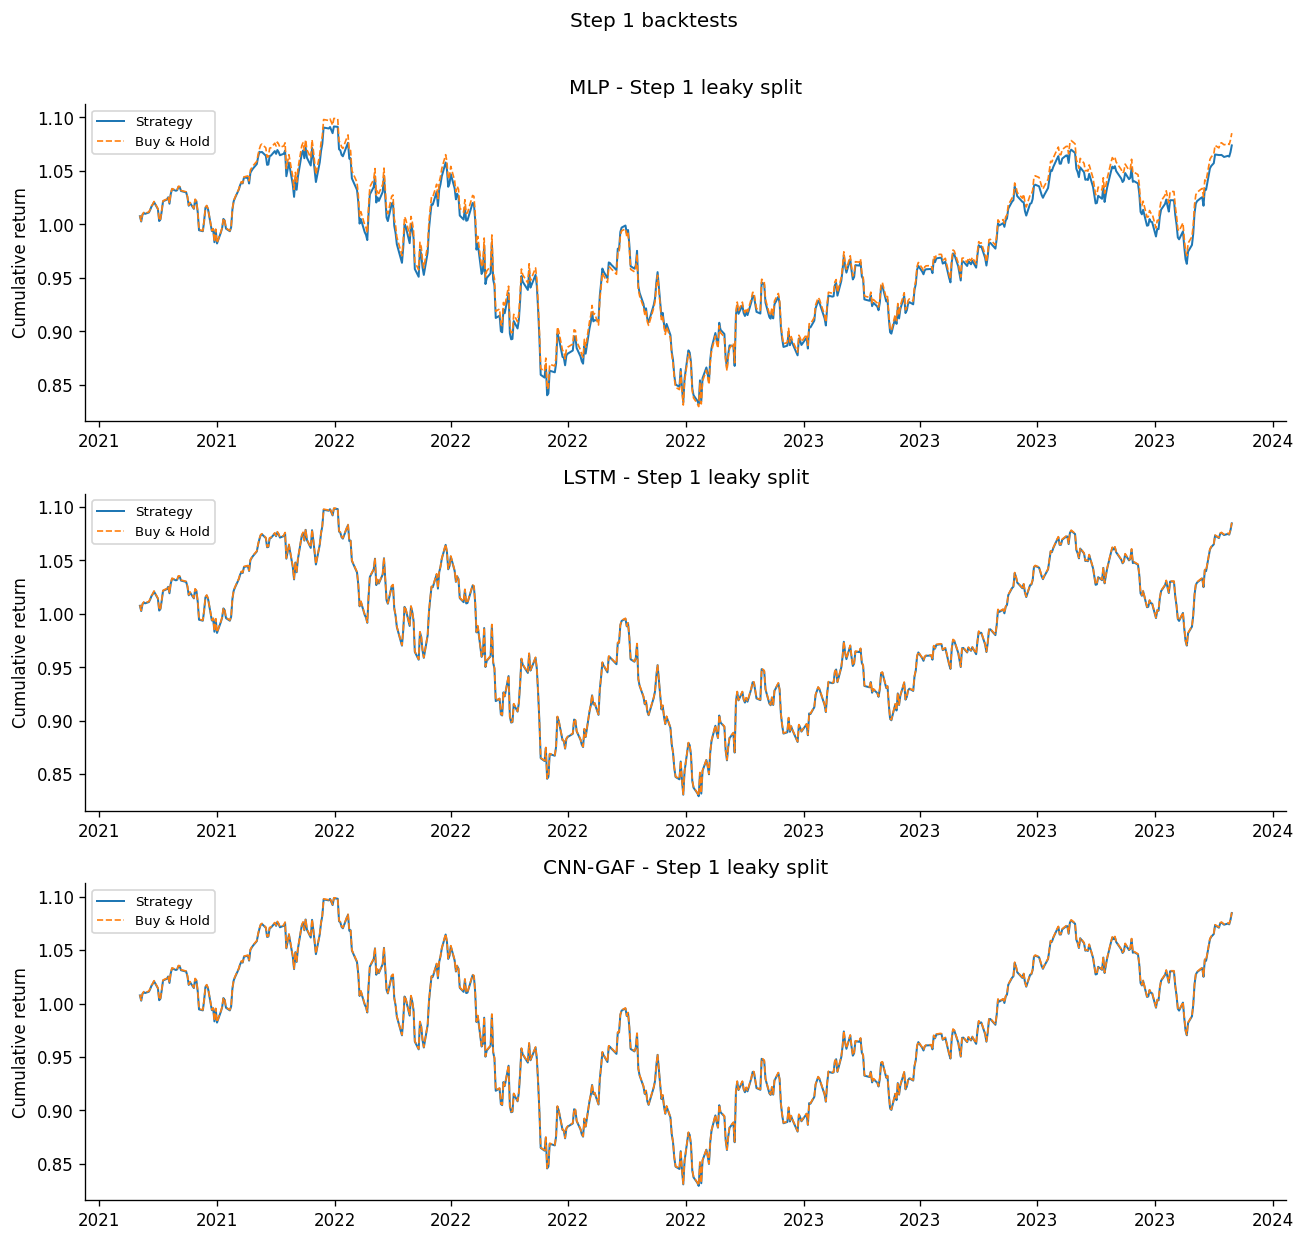

In [31]:
plot_backtests({f"{m} - Step 1 leaky split": bt for m, bt in step1_bt.items()},
               "Step 1 backtests", "fig_02_step1_backtests.png")

## Step 2a and Step 2b. Walk-forward backtesting without embargo

The scaler is fitted only on each training fold. This removes the full-sample normalization leak. However, the label still overlaps at the fold boundary because the label uses the next 20 days.

Step 2a uses 500 observations for training and 500 for testing.  
Step 2b uses 500 observations for training and 100 for testing.

In [32]:
def walk_forward_run(X_raw, y, dates, train_w=500, test_w=500, embargo=0,
                     model_name="MLP", epochs=EPOCHS_WF, max_folds=MAX_FOLDS,
                     protocol=""):
    all_prob = []
    all_y = []
    all_dates = []
    fold_rows = []

    start = 0
    fold = 0
    n = len(y)
    while start + train_w + embargo + test_w <= n:
        tr_start = start
        tr_end = tr_start + train_w
        te_start = tr_end + embargo
        te_end = te_start + test_w

        X_tr_raw = X_raw[tr_start:tr_end]
        y_tr = y[tr_start:tr_end]
        X_te_raw = X_raw[te_start:te_end]
        y_te = y[te_start:te_end]
        d_te = dates[te_start:te_end]

        scaler = StandardScaler().fit(X_tr_raw)
        X_tr = scaler.transform(X_tr_raw).astype("float32")
        X_te = scaler.transform(X_te_raw).astype("float32")

        seed = SEED + fold * 10 + MODEL_ORDER.index(model_name)
        prob = train_predict_model(model_name, X_tr, y_tr, X_te, epochs=epochs, seed=seed)

        all_prob.append(prob)
        all_y.append(y_te)
        all_dates.append(d_te)

        fold_met = clf_metrics(y_te, prob)
        fold_rows.append({
            "Protocol": protocol,
            "Model": model_name,
            "Fold": fold + 1,
            "Train start": dates[tr_start].date(),
            "Train end": dates[tr_end - 1].date(),
            "Test start": dates[te_start].date(),
            "Test end": dates[te_end - 1].date(),
            "AUC-ROC": fold_met["AUC-ROC"],
            "Accuracy": fold_met["Accuracy"],
        })

        fold += 1
        if max_folds is not None and fold >= max_folds:
            break
        start += test_w

    all_prob = np.concatenate(all_prob)
    all_y = np.concatenate(all_y)
    all_dates = pd.Index(np.concatenate([np.asarray(x) for x in all_dates]))

    metrics = clf_metrics(all_y, all_prob)
    metrics.update({"Protocol": protocol, "Model": model_name, "Folds": fold, "Test Obs": len(all_y)})

    bt = backtest_from_predictions(all_dates, all_prob)
    bt_stats = backtest_stats(bt, protocol, model_name)
    fold_df = pd.DataFrame(fold_rows)
    return metrics, bt, bt_stats, fold_df


def run_protocol(protocol, train_w, test_w, embargo):
    metrics_rows = []
    bt_rows = []
    fold_rows = []
    bt_dict = {}

    for model_name in MODEL_ORDER:
        print(f"{protocol}: training {model_name}")
        met, bt, bts, folds = walk_forward_run(
            X_all, y_all, dates_all,
            train_w=train_w, test_w=test_w, embargo=embargo,
            model_name=model_name, protocol=protocol,
        )
        metrics_rows.append(met)
        bt_rows.append(bts)
        fold_rows.append(folds)
        bt_dict[model_name] = bt

    metrics_df = pd.DataFrame(metrics_rows)
    bt_df = pd.DataFrame(bt_rows)
    folds_df = pd.concat(fold_rows, ignore_index=True)
    return metrics_df, bt_df, folds_df, bt_dict

In [33]:
# Step 2a
met_2a, btstat_2a, folds_2a, bt_2a = run_protocol("Step 2a - WF 500/500 no embargo", 500, 500, embargo=0)
display(met_2a)
display(btstat_2a)


Step 2a - WF 500/500 no embargo: training MLP
Step 2a - WF 500/500 no embargo: training LSTM
Step 2a - WF 500/500 no embargo: training CNN-GAF


,Accuracy,Precision,Recall,F1,AUC-ROC,Protocol,Model,Folds,Test Obs
0,0.687,0.7098,0.951,0.8129,0.4623,Step 2a - WF 500/500 no embargo,MLP,2,1000
1,0.715,0.7150,1.000,0.8338,0.4530,Step 2a - WF 500/500 no embargo,LSTM,2,1000
2,0.684,0.7076,0.951,0.8115,0.4822,Step 2a - WF 500/500 no embargo,CNN-GAF,2,1000


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 2a - WF 500/500 no embargo,MLP,57.99,77.55,0.668,0.801,-33.72,0.958,75
1,Step 2a - WF 500/500 no embargo,LSTM,77.46,77.55,0.800,0.801,-33.72,1.000,1
2,Step 2a - WF 500/500 no embargo,CNN-GAF,81.41,77.55,0.835,0.801,-33.72,0.961,27


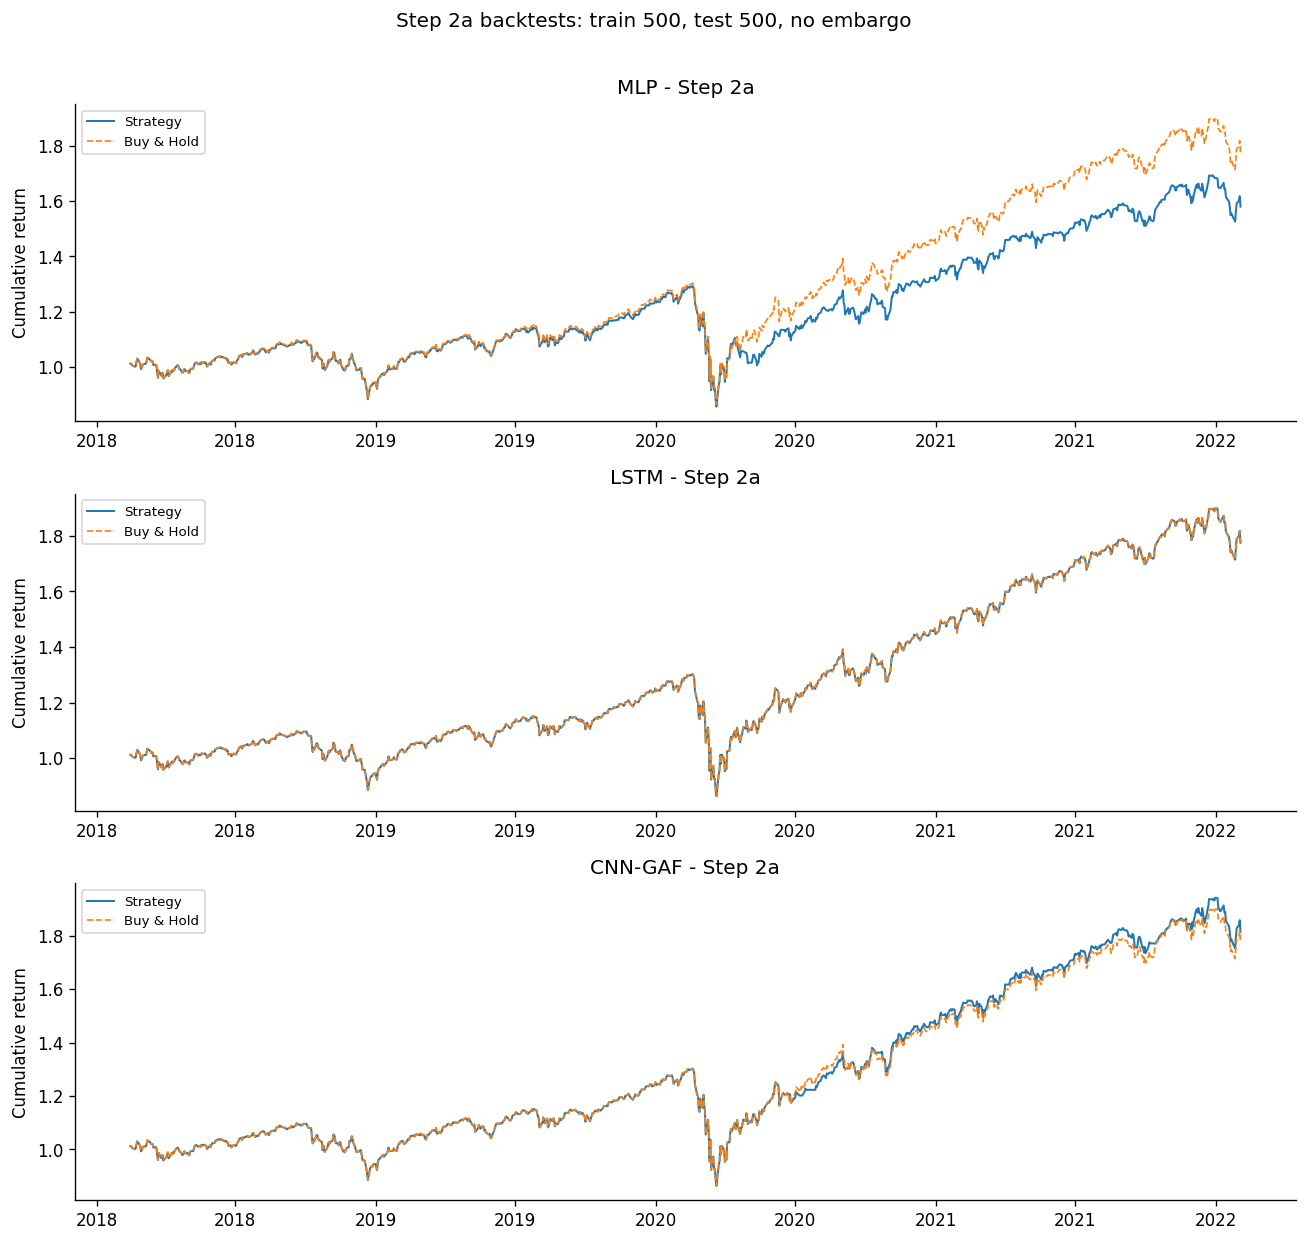

In [34]:
plot_backtests({f"{m} - Step 2a": bt for m, bt in bt_2a.items()},
               "Step 2a backtests: train 500, test 500, no embargo", "fig_03_step2a_backtests.png")

met_2a.to_csv(f"{OUT_DIR}/table_04_step2a_classification.csv", index=False)
btstat_2a.to_csv(f"{OUT_DIR}/table_05_step2a_backtest.csv", index=False)
folds_2a.to_csv(f"{OUT_DIR}/folds_step2a.csv", index=False)

In [35]:
# Step 2b
met_2b, btstat_2b, folds_2b, bt_2b = run_protocol("Step 2b - WF 500/100 no embargo", 500, 100, embargo=0)
display(met_2b)
display(btstat_2b)


Step 2b - WF 500/100 no embargo: training MLP
Step 2b - WF 500/100 no embargo: training LSTM
Step 2b - WF 500/100 no embargo: training CNN-GAF


,Accuracy,Precision,Recall,F1,AUC-ROC,Protocol,Model,Folds,Test Obs
0,0.5836,0.6602,0.7701,0.7110,0.5048,Step 2b - WF 500/100 no embargo,MLP,14,1400
1,0.6371,0.6618,0.9291,0.7730,0.5239,Step 2b - WF 500/100 no embargo,LSTM,14,1400
2,0.6586,0.6628,0.9903,0.7941,0.5842,Step 2b - WF 500/100 no embargo,CNN-GAF,14,1400


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 2b - WF 500/100 no embargo,MLP,4.91,81.35,0.141,0.621,-36.14,0.776,275
1,Step 2b - WF 500/100 no embargo,LSTM,66.38,81.35,0.562,0.621,-33.72,0.934,65
2,Step 2b - WF 500/100 no embargo,CNN-GAF,82.66,81.35,0.629,0.621,-33.72,0.994,5


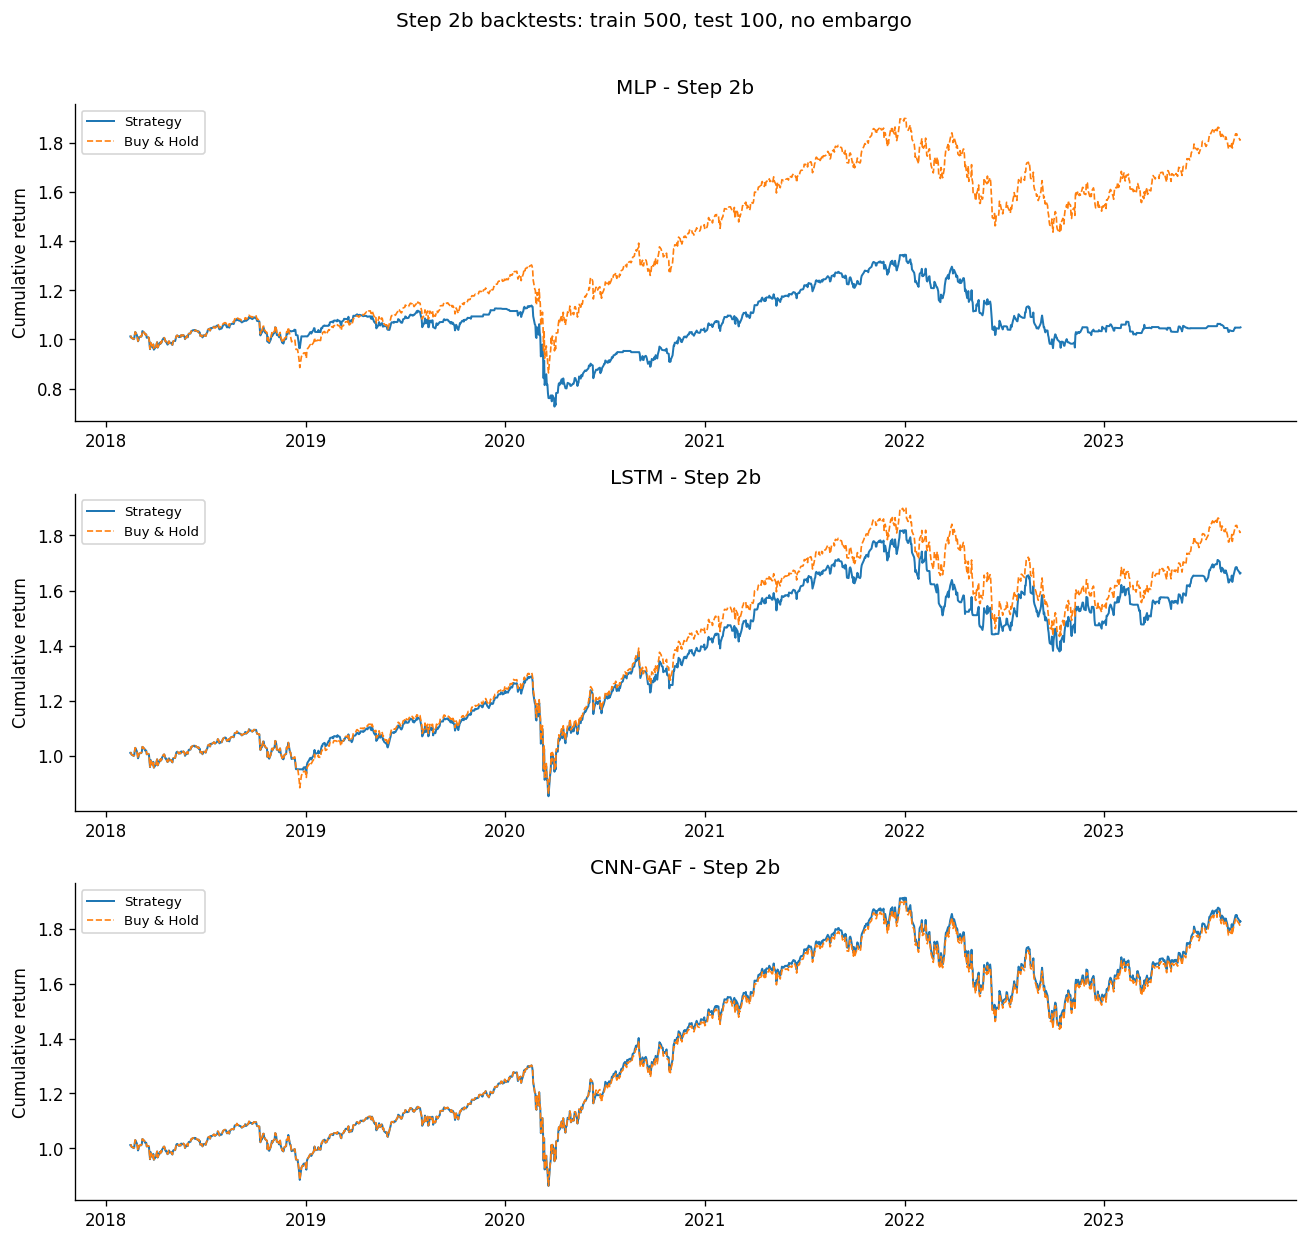

In [36]:
plot_backtests({f"{m} - Step 2b": bt for m, bt in bt_2b.items()},
               "Step 2b backtests: train 500, test 100, no embargo", "fig_04_step2b_backtests.png")

met_2b.to_csv(f"{OUT_DIR}/table_06_step2b_classification.csv", index=False)
btstat_2b.to_csv(f"{OUT_DIR}/table_07_step2b_backtest.csv", index=False)
folds_2b.to_csv(f"{OUT_DIR}/folds_step2b.csv", index=False)

## Step 2c. Compare Step 2 with Step 1

Use the tables above. The main comparison is whether the single leaky split looked better than the walk-forward runs. If it did, the difference is a warning that the first backtest was too optimistic.

## Step 2d. Compare Step 2a with Step 2b

Step 2b retrains the models more often because the test window is shorter. If Step 2b is better, this may mean the model benefits from fresher data. If it is much better, it may also be a sign of backtest overfitting or remaining boundary leakage.

## Step 3a. Method to reduce leakage

We use an embargo. The embargo removes observations between the training window and the test window. Here the embargo length is the label horizon, 20 trading days. This means the training labels near the boundary do not use prices from the test period.

In [37]:
EMBARGO = HORIZON
print("Embargo length:", EMBARGO, "observations")

Embargo length: 20 observations


## Step 3b. Walk-forward 500/500 with embargo

In [38]:
met_3b, btstat_3b, folds_3b, bt_3b = run_protocol("Step 3b - WF 500/500 with embargo", 500, 500, embargo=EMBARGO)
display(met_3b)
display(btstat_3b)


Step 3b - WF 500/500 with embargo: training MLP
Step 3b - WF 500/500 with embargo: training LSTM
Step 3b - WF 500/500 with embargo: training CNN-GAF


,Accuracy,Precision,Recall,F1,AUC-ROC,Protocol,Model,Folds,Test Obs
0,0.693,0.7161,0.9515,0.8172,0.4666,Step 3b - WF 500/500 with embargo,MLP,2,1000
1,0.721,0.7210,1.0000,0.8379,0.4363,Step 3b - WF 500/500 with embargo,LSTM,2,1000
2,0.690,0.7138,0.9515,0.8157,0.4508,Step 3b - WF 500/500 with embargo,CNN-GAF,2,1000


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 3b - WF 500/500 with embargo,MLP,49.87,68.43,0.601,0.734,-33.72,0.958,75
1,Step 3b - WF 500/500 with embargo,LSTM,68.35,68.43,0.733,0.734,-33.72,1.000,1
2,Step 3b - WF 500/500 with embargo,CNN-GAF,72.09,68.43,0.767,0.734,-33.72,0.961,27


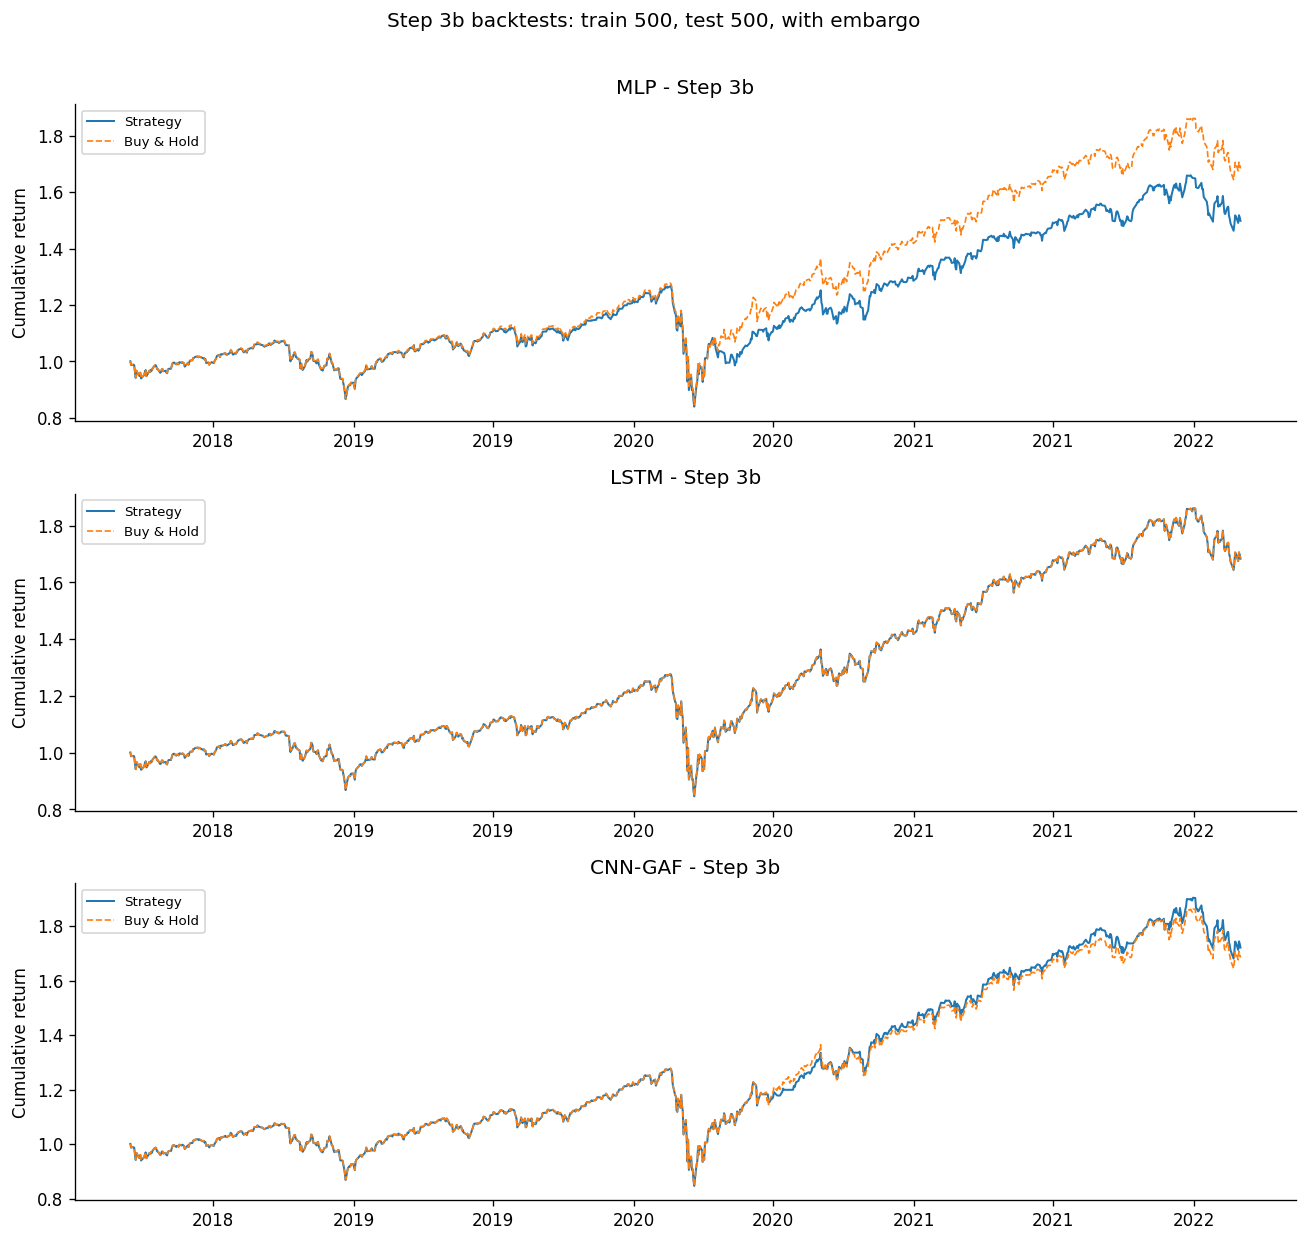

In [39]:
plot_backtests({f"{m} - Step 3b": bt for m, bt in bt_3b.items()},
               "Step 3b backtests: train 500, test 500, with embargo", "fig_05_step3b_backtests.png")

met_3b.to_csv(f"{OUT_DIR}/table_08_step3b_classification.csv", index=False)
btstat_3b.to_csv(f"{OUT_DIR}/table_09_step3b_backtest.csv", index=False)
folds_3b.to_csv(f"{OUT_DIR}/folds_step3b.csv", index=False)

## Step 3c. Walk-forward 500/100 with embargo

In [40]:
met_3c, btstat_3c, folds_3c, bt_3c = run_protocol("Step 3c - WF 500/100 with embargo", 500, 100, embargo=EMBARGO)
display(met_3c)
display(btstat_3c)


Step 3c - WF 500/100 with embargo: training MLP
Step 3c - WF 500/100 with embargo: training LSTM
Step 3c - WF 500/100 with embargo: training CNN-GAF


,Accuracy,Precision,Recall,F1,AUC-ROC,Protocol,Model,Folds,Test Obs
0,0.5821,0.6581,0.7694,0.7094,0.5005,Step 3c - WF 500/100 with embargo,MLP,14,1400
1,0.6357,0.6579,0.9386,0.7735,0.5301,Step 3c - WF 500/100 with embargo,LSTM,14,1400
2,0.6486,0.6580,0.9784,0.7868,0.5709,Step 3c - WF 500/100 with embargo,CNN-GAF,14,1400


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 3c - WF 500/100 with embargo,MLP,-7.36,72.01,0.023,0.575,-36.19,0.775,269
1,Step 3c - WF 500/100 with embargo,LSTM,52.84,72.01,0.482,0.575,-33.72,0.946,59
2,Step 3c - WF 500/100 with embargo,CNN-GAF,71.03,72.01,0.572,0.575,-33.72,0.986,9


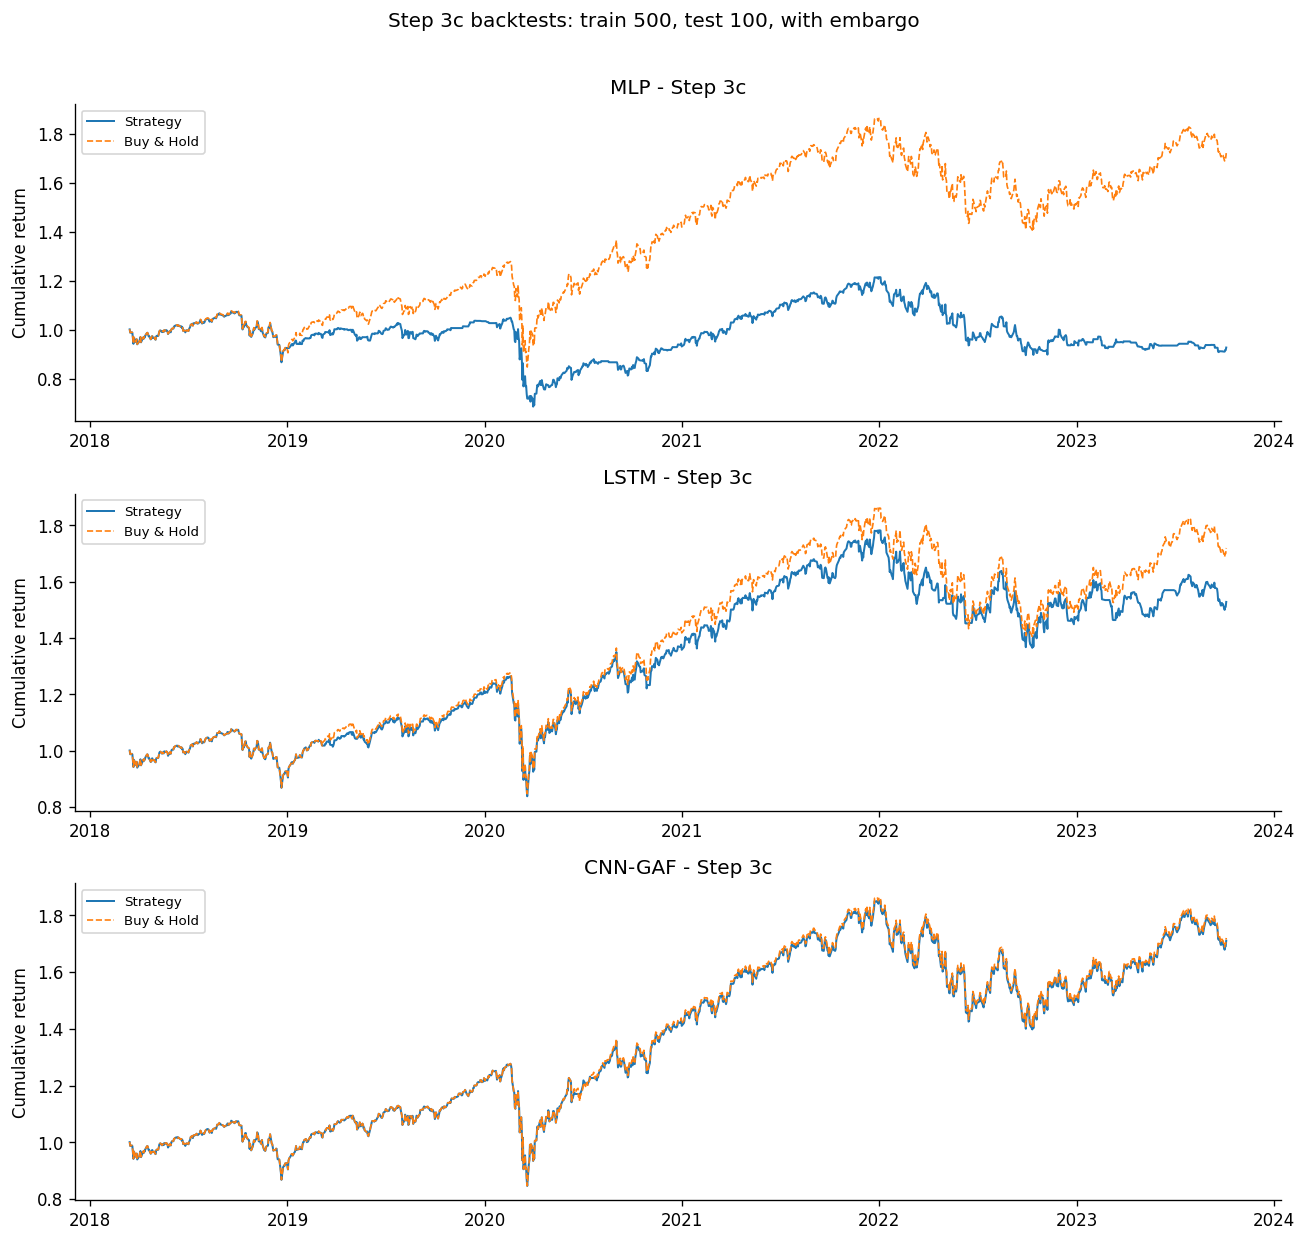

In [41]:
plot_backtests({f"{m} - Step 3c": bt for m, bt in bt_3c.items()},
               "Step 3c backtests: train 500, test 100, with embargo", "fig_06_step3c_backtests.png")

met_3c.to_csv(f"{OUT_DIR}/table_10_step3c_classification.csv", index=False)
btstat_3c.to_csv(f"{OUT_DIR}/table_11_step3c_backtest.csv", index=False)
folds_3c.to_csv(f"{OUT_DIR}/folds_step3c.csv", index=False)

## Step 3d. Compare Step 3b and Step 3c. Check if overfitting disappeared

The embargo results are the cleanest results in this notebook. If the performance is closer to random after the embargo, that means the previous runs probably benefited from leakage. If performance remains stable, then the models may have learned a small real signal. The decision should be based on AUC, Sharpe ratio, drawdown, and the gap against buy-and-hold.

In [42]:
# Consolidated tables.
classification_summary = pd.concat([
    step1_metrics_df,
    met_2a[["Protocol", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "Folds", "Test Obs"]],
    met_2b[["Protocol", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "Folds", "Test Obs"]],
    met_3b[["Protocol", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "Folds", "Test Obs"]],
    met_3c[["Protocol", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "Folds", "Test Obs"]],
], ignore_index=True)

backtest_summary = pd.concat([
    step1_bt_df,
    btstat_2a,
    btstat_2b,
    btstat_3b,
    btstat_3c,
], ignore_index=True)

classification_summary.to_csv(f"{OUT_DIR}/summary_classification.csv", index=False)
backtest_summary.to_csv(f"{OUT_DIR}/summary_backtest.csv", index=False)

print("Classification summary")
display(classification_summary)
print("Backtest summary")
display(backtest_summary)

Classification summary


,Protocol,Model,Accuracy,Precision,Recall,F1,AUC-ROC,Folds,Test Obs
0,Step 1 - leaky single split,MLP,0.5357,0.5397,0.9812,0.6963,0.5219,NaN,NaN
1,Step 1 - leaky single split,LSTM,0.5425,0.5425,1.0000,0.7034,0.4863,NaN,NaN
2,Step 1 - leaky single split,CNN-GAF,0.5425,0.5425,1.0000,0.7034,0.4804,NaN,NaN
3,Step 2a - WF 500/500 no embargo,MLP,0.6870,0.7098,0.9510,0.8129,0.4623,2.0,1000.0
4,Step 2a - WF 500/500 no embargo,LSTM,0.7150,0.7150,1.0000,0.8338,0.4530,2.0,1000.0
5,Step 2a - WF 500/500 no embargo,CNN-GAF,0.6840,0.7076,0.9510,0.8115,0.4822,2.0,1000.0
6,Step 2b - WF 500/100 no embargo,MLP,0.5836,0.6602,0.7701,0.7110,0.5048,14.0,1400.0
7,Step 2b - WF 500/100 no embargo,LSTM,0.6371,0.6618,0.9291,0.7730,0.5239,14.0,1400.0
8,Step 2b - WF 500/100 no embargo,CNN-GAF,0.6586,0.6628,0.9903,0.7941,0.5842,14.0,1400.0
9,Step 3b - WF 500/500 with embargo,MLP,0.6930,0.7161,0.9515,0.8172,0.4666,2.0,1000.0


Backtest summary


,Protocol,Model,Total Return,Buy & Hold Return,Sharpe,B&H Sharpe,Max Drawdown,Exposure,Trades
0,Step 1 - leaky single split,MLP,7.38,8.53,0.257,0.281,-23.74,0.986,15
1,Step 1 - leaky single split,LSTM,8.47,8.53,0.280,0.281,-24.50,1.000,1
2,Step 1 - leaky single split,CNN-GAF,8.47,8.53,0.280,0.281,-24.50,1.000,1
3,Step 2a - WF 500/500 no embargo,MLP,57.99,77.55,0.668,0.801,-33.72,0.958,75
4,Step 2a - WF 500/500 no embargo,LSTM,77.46,77.55,0.800,0.801,-33.72,1.000,1
5,Step 2a - WF 500/500 no embargo,CNN-GAF,81.41,77.55,0.835,0.801,-33.72,0.961,27
6,Step 2b - WF 500/100 no embargo,MLP,4.91,81.35,0.141,0.621,-36.14,0.776,275
7,Step 2b - WF 500/100 no embargo,LSTM,66.38,81.35,0.562,0.621,-33.72,0.934,65
8,Step 2b - WF 500/100 no embargo,CNN-GAF,82.66,81.35,0.629,0.621,-33.72,0.994,5
9,Step 3b - WF 500/500 with embargo,MLP,49.87,68.43,0.601,0.734,-33.72,0.958,75


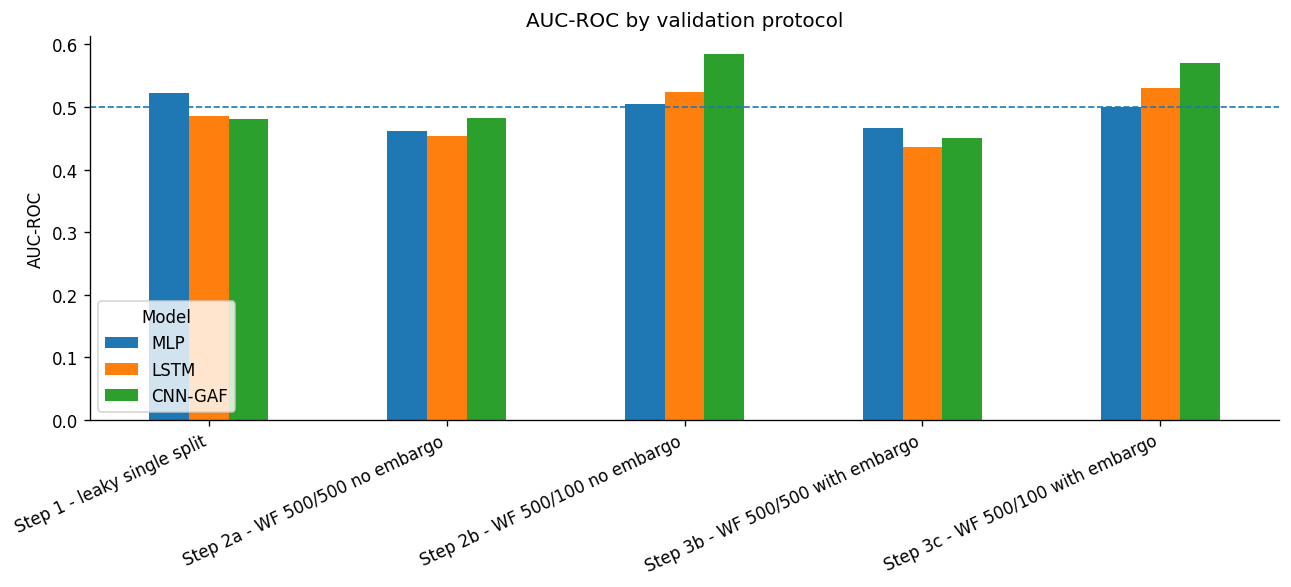

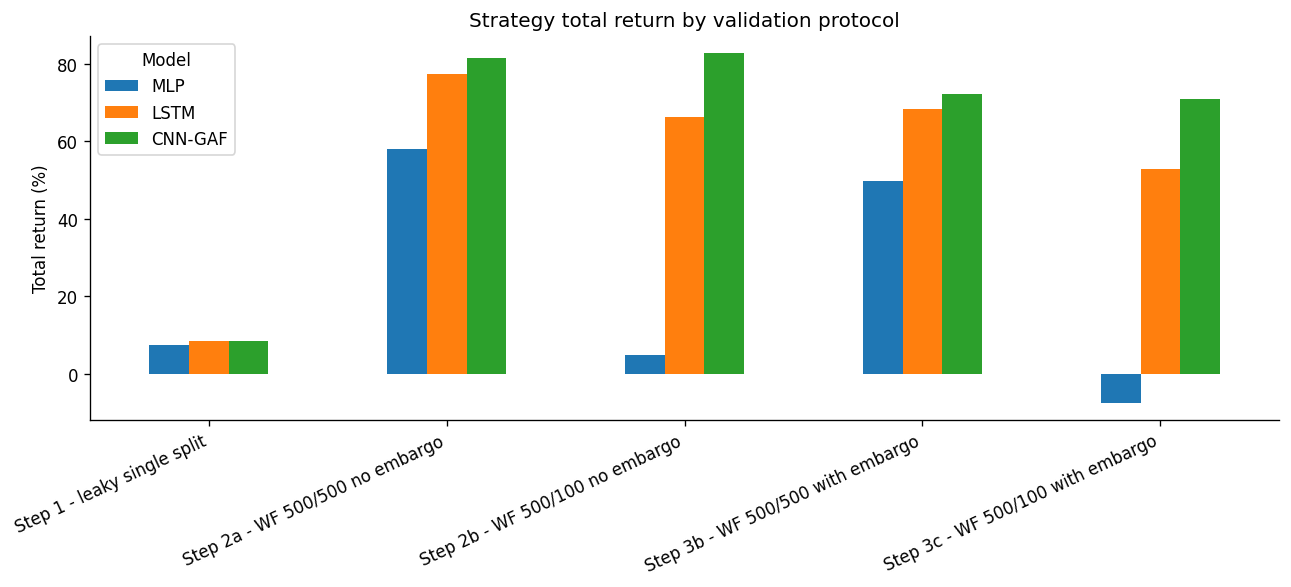

In [43]:
# AUC progression figure for the report.
auc_plot = classification_summary.pivot_table(index="Protocol", columns="Model", values="AUC-ROC", aggfunc="first")
protocol_order = [
    "Step 1 - leaky single split",
    "Step 2a - WF 500/500 no embargo",
    "Step 2b - WF 500/100 no embargo",
    "Step 3b - WF 500/500 with embargo",
    "Step 3c - WF 500/100 with embargo",
]
auc_plot = auc_plot.loc[[p for p in protocol_order if p in auc_plot.index], MODEL_ORDER]

fig, ax = plt.subplots(figsize=(11, 5))
auc_plot.plot(kind="bar", ax=ax)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC by validation protocol")
ax.set_xlabel("")
ax.legend(title="Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_07_auc_progression.png", bbox_inches="tight")
plt.show()

# Return progression figure.
return_plot = backtest_summary.pivot_table(index="Protocol", columns="Model", values="Total Return", aggfunc="first")
return_plot = return_plot.loc[[p for p in protocol_order if p in return_plot.index], MODEL_ORDER]
fig, ax = plt.subplots(figsize=(11, 5))
return_plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Total return (%)")
ax.set_title("Strategy total return by validation protocol")
ax.set_xlabel("")
ax.legend(title="Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_08_return_progression.png", bbox_inches="tight")
plt.show()

In [44]:
# Optional: make a zip file of tables and figures for download.
import shutil
zip_path = shutil.make_archive("/content/gwp2_outputs", "zip", OUT_DIR)
print("Saved output zip:", zip_path)
print("Main files:")
print("- summary_classification.csv")
print("- summary_backtest.csv")
print("- fig_01_data_description.png")
print("- fig_07_auc_progression.png")
print("- fig_08_return_progression.png")

Saved output zip: /content/gwp2_outputs.zip
Main files:
- summary_classification.csv
- summary_backtest.csv
- fig_01_data_description.png
- fig_07_auc_progression.png
- fig_08_return_progression.png
